# Introduction to Epidemiology

**Institution:** Institut Pasteur de Tunis & Africa CDC  
**Date:** April 16, 2026  

**Instructor:** Prof. Slimane Ben Miled  

---

## Overview

This lecture introduces the fundamental concepts of epidemiology and infectious disease modeling.  
It provides a foundation for understanding how diseases spread within populations, using mathematical models such as the SIR and SEIR frameworks.

The session will cover:
- Basic epidemiological concepts  
- Compartmental models (SIR, SEIR)  
- Interpretation of model dynamics  
- Applications to public health and decision-making  

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as spi


# SIR Model Description



A simple mathematical description of the spread of a disease in a population is given by the **SIR model**. The population is divided into three compartments:

- **S(t)**: Susceptible individuals  
- **I(t)**: Infected (infectious) individuals  
- **R(t)**: Recovered individuals (with immunity)  

## SIR Model Equations

The dynamics of the SIR model are described by the following system of differential equations:

$$
\frac{dS}{dt} = -\beta S I/N
$$

$$
\frac{dI}{dt} = \beta S I/N - \gamma I
$$

$$
\frac{dR}{dt} = \gamma I
$$

The total population is assumed to remain constant:

$$
S(t) + I(t) + R(t) = 1
$$

## Model Parameters

The model is governed by two parameters:

- $\beta$ **(beta)**: transmission rate  
- $\gamma$ **(gamma)**: recovery rate  
  - \(1/\gamma\) represents the infectious period  
- $N$ : Total population

In [12]:
def dydt(SI, t, beta, gamma, N=1):
    """
    System of differential equations for the SIR model
    """
    S, I = SI
    dSdt = -beta * S * I/N
    dIdt = beta * S * I/N - gamma * I
    return [dSdt, dIdt]

In [13]:
# -----------------------------
# TIME PARAMETERS
# -----------------------------
t_start = 0.0
t_end = 100
dt = 0.1
t_range = np.arange(t_start, t_end, dt)

# -----------------------------
# INITIAL CONDITIONS
# -----------------------------
N=1
I0 = 1e-7          # Initial proportion of infected individuals
S0 = 1 - I0        # Initial susceptible population
X0 = (S0, I0)


In [14]:
# -----------------------------
# MODEL PARAMETERS
# -----------------------------
R0 = 0.8
gamma = 1 / 4
beta = R0 * gamma

# -----------------------------
# SOLVING THE SYSTEM
# -----------------------------
RES = spi.odeint(dydt, X0, t_range, args=(beta, gamma))

S = RES[:, 0]
I = RES[:, 1]
R = 1 - S - I

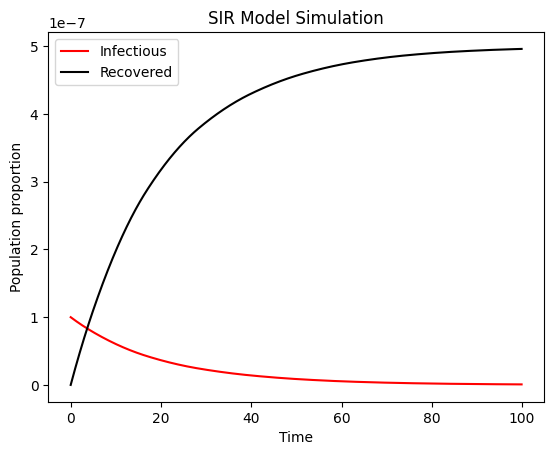

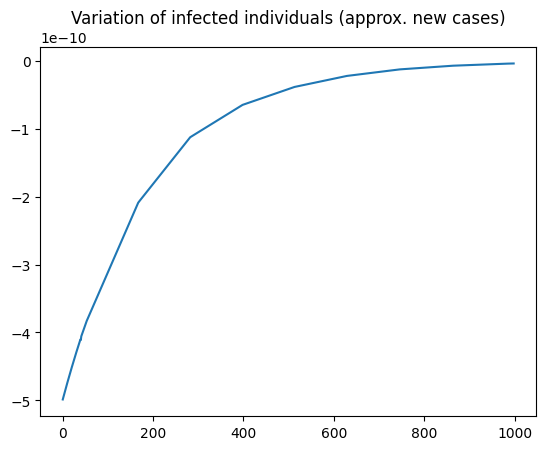

In [15]:
# -----------------------------
# PLOTTING RESULTS
# -----------------------------
plt.figure()
plt.plot(t_range, I, '-r', label='Infectious')
plt.plot(t_range, R, '-k', label='Recovered')
plt.xlabel('Time')
plt.ylabel('Population proportion')
plt.legend()
plt.title('SIR Model Simulation')
plt.show()

# -----------------------------
# OPTIONAL: DAILY NEW CASES (approximation)
# -----------------------------
plt.figure()
plt.plot(np.diff(I))
plt.title("Variation of infected individuals (approx. new cases)")
plt.show()

## Simulation Questions

1. Run the model with different values of $\beta$. What do you observe?

2. Run the model with different values of $\gamma$. What changes in the epidemic curve?

3. What happens when initial value of $R(0)$ is smaller than 1? What happens when it is greater than 1?

4. How does the value of $I(0)$ influence the beginning of the epidemic?

5. Find the epidemic peak:
   - When does it occur?
   - What is the maximum value of $I(t)$?

6. What is the final value of $R(t)$?
   What does it mean?

7. Explain why $S(t)$ decreases over time.

8. Explain why $I(t)$ first increases and then decreases.

9. Explain the effect of total population, $N$, on the evolution of the epidemic
10. Based on the simulation, what parameters are the most important for controlling the epidemic?

#Extension: Modeling a Control Measure (e.g. Lockdown)

In [16]:
# Time-varying reproduction number (intervention scenario)
def R0_time(t):
    return 2 if t < 70 else 0.5

gamma = 1 / 4

def dydt_control(SI, t, gamman, N=1):
    S, I = SI
    beta = R0_time(t)/N * gamma
    dSdt = -beta * S * I
    dIdt = beta * S * I - gamma * I
    return [dSdt, dIdt]



In [17]:
RES = spi.odeint(dydt_control, X0, t_range, args=(gamma,))

S = RES[:, 0]
I = RES[:, 1]
R = 1 - S - I



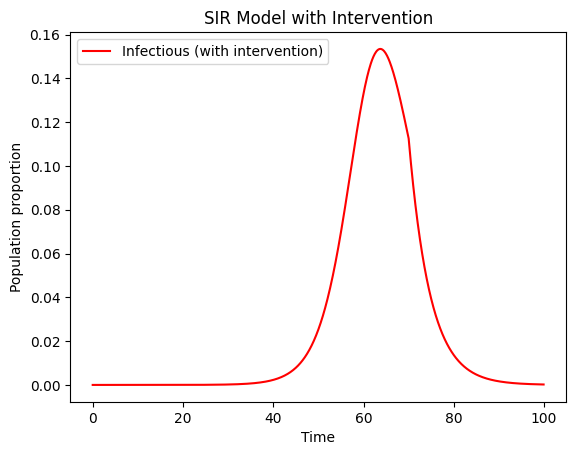

In [18]:
plt.figure()
plt.plot(t_range, I, '-r', label='Infectious (with intervention)')
plt.xlabel('Time')
plt.ylabel('Population proportion')
plt.legend()
plt.title('SIR Model with Intervention')
plt.show()


10. Simulate a lockdown by reducing \(\beta\) after a given time.
What happens to the epidemic peak?
11. Simulate the introduction of a lockdown at different times during the epidemic.
    1.   How does the timing of intervention influence its effectiveness in controlling disease spread?
    2.   Discuss the trade-off between early intervention and delayed response.



# SEIR Model Description

The SEIR model describes the spread of an infectious disease in a population divided into four compartments:

- **S(t)**: Susceptible individuals (can be infected)
- **E(t)**: Exposed individuals (infected but not yet infectious)
- **I(t)**: Infectious individuals (can transmit the disease)
- **R(t)**: Recovered individuals (immune)

The total population is assumed to be constant:

\[
S(t) + E(t) + I(t) + R(t) = 1
\]

### SEIR Model Equations

The dynamics of the system are given by:

$$
\frac{dS}{dt} = -\beta S I
$$

$$
\frac{dE}{dt} = \beta S I - \sigma E
$$

$$
\frac{dI}{dt} = \sigma E - \gamma I
$$

$$
\frac{dR}{dt} = \gamma I
$$

### Incidence (New Cases)

The number of new infectious cases per unit time is:

$$
\text{Incidence}(t) = \sigma E(t)
$$

This represents individuals becoming infectious.

## Model Parameters

-  $\beta$ **(beta)**: transmission rate  
- σ **(sigma)**: progression rate from exposed to infectious  
  - \(1/\sigma\): average incubation period  
- γ **(gamma)**: recovery rate  
  - $1/\gamma$: average infectious period  

In [20]:
# -----------------------------
# INITIAL CONDITIONS
# -----------------------------
I0 = 1e-7          # Initial infectious proportion
E0 = 0.0           # Initial exposed proportion
R0_init = 0.0      # Initial recovered proportion
S0 = 1 - I0 - E0 - R0_init

X0 = (S0, E0, I0, R0_init)

In [21]:
def dydt(X, t, beta, sigma, gamma):
    S, E, I, R = X
    dSdt = -beta * S * I
    dEdt = beta * S * I - sigma * E
    dIdt = sigma * E - gamma * I
    dRdt = gamma * I
    return [dSdt, dEdt, dIdt, dRdt]


In [22]:
# -----------------------------
# MODEL PARAMETERS
# -----------------------------
R0_value = 2.5         # Basic reproduction number
gamma = 1 / 4          # Infectious period = 4 days
sigma = 1 / 5          # Incubation period = 5 days
beta = R0_value * gamma

# -----------------------------
# SOLVING THE SYSTEM
# -----------------------------
RES = spi.odeint(dydt, X0, t_range, args=(beta, sigma, gamma))

S = RES[:, 0]
E = RES[:, 1]
I = RES[:, 2]
R = RES[:, 3]

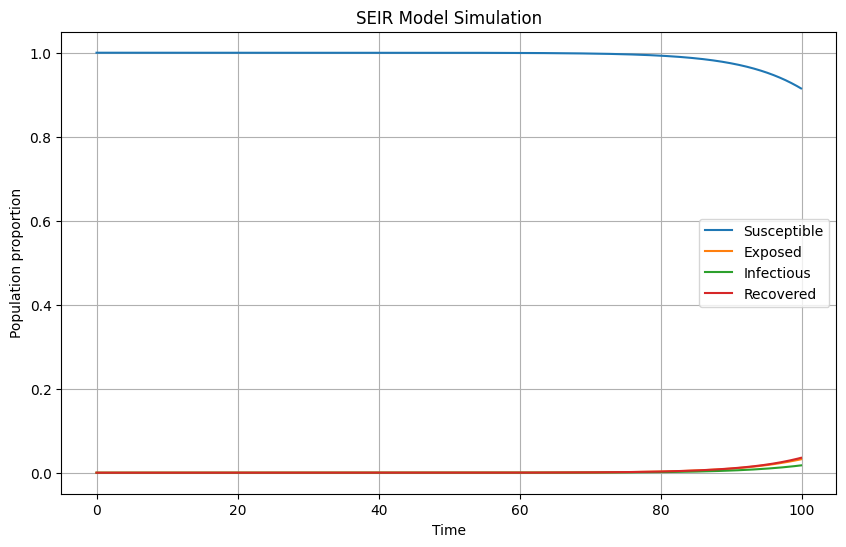

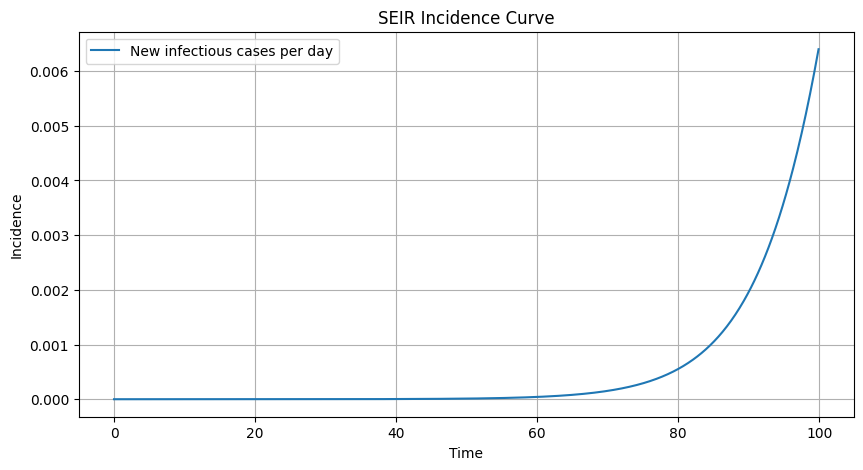

In [23]:
# -----------------------------
# PLOTTING RESULTS
# -----------------------------
plt.figure(figsize=(10, 6))
plt.plot(t_range, S, label='Susceptible')
plt.plot(t_range, E, label='Exposed')
plt.plot(t_range, I, label='Infectious')
plt.plot(t_range, R, label='Recovered')
plt.xlabel('Time')
plt.ylabel('Population proportion')
plt.title('SEIR Model Simulation')
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# OPTIONAL: APPROXIMATE DAILY NEW INFECTIOUS CASES
# -----------------------------
new_cases = sigma * E

plt.figure(figsize=(10, 5))
plt.plot(t_range, new_cases, label='New infectious cases per day')
plt.xlabel('Time')
plt.ylabel('Incidence')
plt.title('SEIR Incidence Curve')
plt.legend()
plt.grid(True)
plt.show()

## Exercises

1. Change initial value of the recovery $R(0)$ and observe the impact on the epidemic  
2. Modify the incubation period ($\sigma$)  
3. Add a control strategy (reduce $\beta$ over time)  
4. Compute the peak of infection  
5. Compute the final epidemic size  
6. Deduice the effect of adding the $E$ compartment on the dynamic of the epidemic

## Advanced Extension

- Time-dependent transmission rate: \(\beta(t)\)  
- SEIR with intervention strategies  
- SEIR with environmental or climate effects  
- SEIR with vector dynamics (mosquito-borne diseases)  